# Python Intermedio, primera parte — Sesión 3

En esta sesión veremos:

- Manejo de fechas e índices temporales.
- Cambio de frecuencia y agregación (`resample`), (`rolling`).
- Cálculo de tasas de variación y acumulación temporal.
- Visualización con Matplotlib y Seaborn.
- Personalización de gráficos (colores, estilos, títulos, ejes).
- Visualizaciones comparativas y análisis de tendencias.


La idea es que **tú escribas código** en varias celdas en blanco, no solo mirar.  
Si algo falla: ¡mejor! Aprendemos depurando

## 0. Simulación de la base de datos

En esta celda se simula una base de datos de 60 días de ventas diarias. El resultado se guarda en el `DataFrame` `df`.


In [6]:
import pandas as pd
import numpy as np

# Simulamos una base de datos de 60 días de ventas diarias
np.random.seed(42)
fechas = pd.date_range(start='2024-01-01', periods=60, freq='D')
tendencia = np.linspace(100, 160, 60)  # tendencia creciente suave
ruido = np.random.randint(-10, 11, size=60)  # ruido entre -10 y 10
monto = tendencia + ruido

df = pd.DataFrame({
    'fecha': fechas,
    'monto': np.round(monto, 2)
})

df.head()

,fecha,monto
0,2024-01-01,96.00
1,2024-01-02,110.02
2,2024-01-03,106.03
3,2024-01-04,103.05
4,2024-01-05,101.07


## 1. Manejo de fechas e índices temporales

En esta parte trabajaremos con la columna `fecha` para:
- Asegurar que está en formato de fecha.
- Convertirla en índice del `DataFrame`.
- Crear variables de año, mes y día de la semana.


### **ACTIVIDAD 1: Manejo de fechas e índices temporales**

**Objetivos:**
1. Convertir la columna **`fecha`** al formato `datetime`.
2. Establecer **`fecha`** como índice del DataFrame.
3. Crear las columnas:  
   - **`anio`**  
   - **`mes`**  
   - **`dia_semana`**

**Pistas:**
- Usa `pd.to_datetime(df['fecha'])` para convertir la columna.
- Para establecer **`fecha`** como índice, puedes usar `df.set_index('fecha', inplace=True)`.
- Para obtener año y mes, utiliza:  
  - `df.index.year`  
  - `df.index.month`
- Para obtener el día de la semana, revisa `df.index.day_name()`.

In [7]:
df['fecha'] = pd.to_datetime(df['fecha'])
df = df.set_index('fecha')

df['anio'] = df.index.year
df['mes'] = df.index.month
try:
    df['dia_semana'] = df.index.day_name(locale='es_ES')
except TypeError:
    df['dia_semana'] = df.index.day_name()

df.head()

Error: unsupported locale setting

## 2. Cambio de frecuencia y agregación (`resample`) y medias móviles (`rolling`)

En esta parte trabajaremos con:
- Cambio de frecuencia de diaria a semanal usando `resample`.
- Cálculo de medias móviles para suavizar la serie usando `rolling`.


### **ACTIVIDAD 2: Resample y medias móviles**

**Objetivos:**
1. Crear una serie de ventas **semanales (suma)** a partir de la columna **`monto`**.
2. Calcular una **media móvil de 7 días** sobre la columna **`monto`**.

**Pistas:**
- Para obtener la serie semanal, usa:  
  `df['monto'].resample('W').sum()`
- Para calcular la media móvil de 7 días, puedes usar:  
  `df['monto'].rolling(7).mean()`

In [8]:
df_semanal = df['monto'].resample('W').sum()
df['monto_mm7'] = df['monto'].rolling(7).mean()

print("Ventas semanales (suma):")
print(df_semanal.head())

print("\nVista de la serie con media móvil de 7 días:")
df[['monto', 'monto_mm7']].head(15)

Ventas semanales (suma):
fecha
2024-01-07    733.35
2024-01-14    771.19
2024-01-21    809.02
2024-01-28    890.85
2024-02-04    928.68
Freq: W-SUN, Name: monto, dtype: float64

Vista de la serie con media móvil de 7 días:


,monto,monto_mm7
fecha,,
2024-01-01,96.00,NaN
2024-01-02,110.02,NaN
2024-01-03,106.03,NaN
2024-01-04,103.05,NaN
2024-01-05,101.07,NaN
2024-01-06,115.08,NaN
2024-01-07,102.10,104.764286
2024-01-08,115.12,107.495714
2024-01-09,108.14,107.227143


## 3. Tasas de variación y acumulación temporal

Ahora trabajaremos con:
- La variación porcentual diaria del monto usando `pct_change`.
- El monto acumulado en el tiempo usando `cumsum`.

La variación porcentual entre dos periodos consecutivos se calcula como:

$$\text{Var\%}_t = \frac{x_t - x_{t-1}}{x_{t-1}} \times 100$$


### **ACTIVIDAD 3: Variación porcentual y acumulado**

**Objetivos:**
1. Crear la columna **`var_pct`** con la **variación porcentual diaria** de la columna `monto`.
2. Crear la columna **`acumulado`** con el **monto acumulado** a lo largo del tiempo.

**Pistas:**
- Para calcular la variación porcentual diaria, usa:  
  `df['monto'].pct_change() * 100`
- Para obtener el monto acumulado, utiliza:  
  `df['monto'].cumsum()`


In [9]:
df['var_pct'] = df['monto'].pct_change() * 100
df['acumulado'] = df['monto'].cumsum()

df[['monto', 'var_pct', 'acumulado']].head(10)

,monto,var_pct,acumulado
fecha,,,
2024-01-01,96.00,NaN,96.00
2024-01-02,110.02,14.604167,206.02
2024-01-03,106.03,-3.626613,312.05
2024-01-04,103.05,-2.810525,415.10
2024-01-05,101.07,-1.921397,516.17
2024-01-06,115.08,13.861680,631.25
2024-01-07,102.10,-11.279110,733.35
2024-01-08,115.12,12.752204,848.47
2024-01-09,108.14,-6.063238,956.61


## 4. Visualización con Matplotlib y Seaborn

En esta parte vamos a graficar la serie de ventas diarias. Usaremos:

- `matplotlib.pyplot` para un gráfico de línea básico.
- `seaborn` para un gráfico similar con estilos predefinidos.


### **ACTIVIDAD 4: Gráfico de la serie de ventas**

**Objetivos:**
1. Graficar la serie **`monto`** en el tiempo utilizando **Matplotlib**.
2. Repetir el gráfico usando **Seaborn**.

**Pistas:**
- Para graficar con Matplotlib, puedes usar:  
  `plt.plot(df.index, df['monto'])`
- Recuerda añadir **título** y **etiquetas de ejes**.
- Para graficar con Seaborn, utiliza:  
  `sns.lineplot(x=df.index, y=df['monto'])`


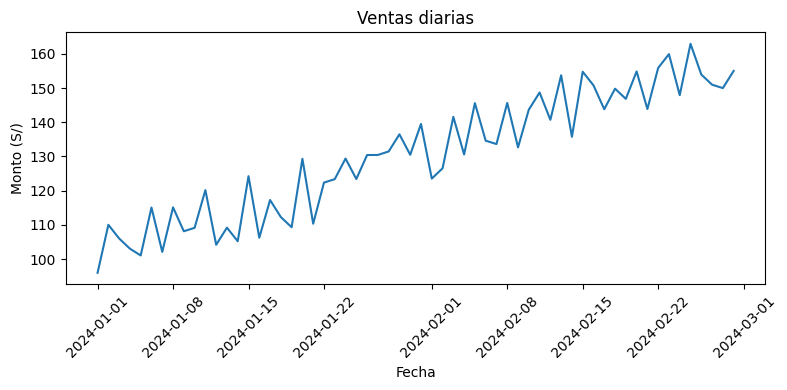

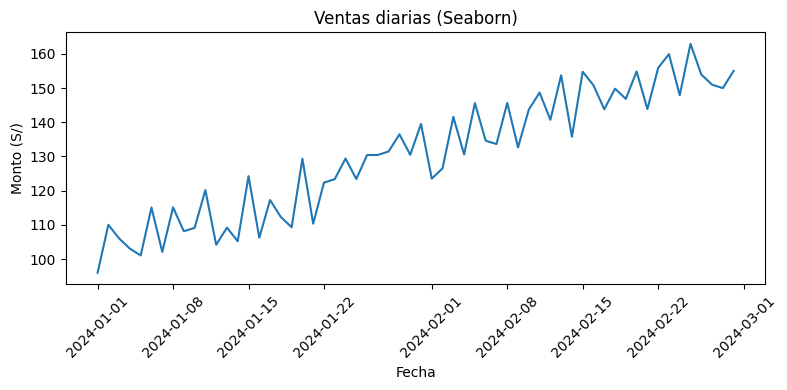

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.plot(df.index, df['monto'])
plt.title('Ventas diarias')
plt.xlabel('Fecha')
plt.ylabel('Monto (S/)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(x=df.index, y=df['monto'])
plt.title('Ventas diarias (Seaborn)')
plt.xlabel('Fecha')
plt.ylabel('Monto (S/)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Personalización de gráficos

La personalización permite adaptar los gráficos al estilo de cada persona o al formato de un informe. Algunas ideas para experimentar:

- Cambiar el estilo global con `plt.style.use('ggplot')`, `plt.style.use('seaborn-v0_8-darkgrid')`, entre otros.
- Cambiar el color (`color='red'`, `'green'`, etc.), el grosor de la línea (`linewidth`) y el marcador (`marker='o'`, `'s'`, `'x'`).
- Ajustar los límites del eje Y con `plt.ylim()`.
- Añadir rejilla con `plt.grid(True)`.
- En Seaborn, se pueden usar `sns.set_style()` y `sns.set_palette()` para cambiar el fondo y la paleta de colores.


### **ACTIVIDAD 5: Gráfico personalizado**

**Objetivos:**
1. Elegir un **estilo global** para los gráficos.
2. Graficar la serie **`monto`** usando un **color**, **marcador** y **grosor de línea** elegidos por ti.
3. Añadir **título**, **etiquetas de ejes** y **rejilla**.

**Pistas:**
- Usa `plt.style.use(...)` para seleccionar un estilo.
- Prueba distintos valores de:  
  - `color`  
  - `linewidth`  
  - `marker`


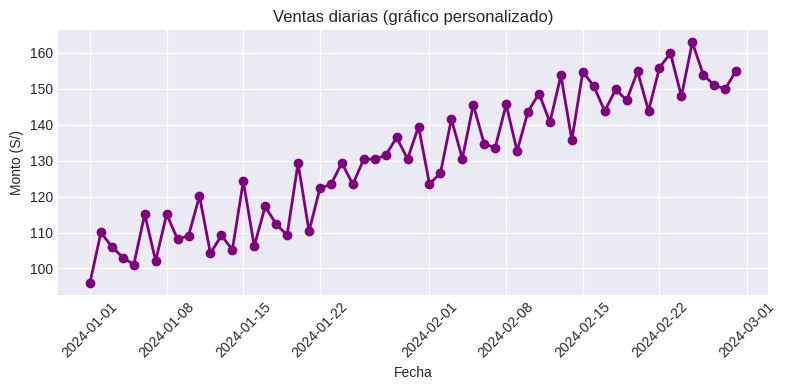

In [11]:
plt.style.use('seaborn-v0_8-darkgrid')

plt.figure(figsize=(8, 4))
plt.plot(df.index, df['monto'], color='purple', linewidth=2, marker='o')
plt.title('Ventas diarias (gráfico personalizado)')
plt.xlabel('Fecha')
plt.ylabel('Monto (S/)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Visualizaciones comparativas y análisis de tendencias

La comparación entre la serie original y una media móvil ayuda a distinguir el ruido de corto plazo de la tendencia subyacente.


### **ACTIVIDAD 6: Serie original vs media móvil**

**Objetivos:**
1. Graficar en una misma figura la serie original **`monto`**.
2. Añadir la serie de **media móvil de 7 días (`monto_mm7`)** en el mismo gráfico.
3. Incluir **leyenda**, **título** y **etiquetas de ejes**.

**Pistas:**
- Usa `plt.plot(...)` para graficar cada serie.
- Utiliza `plt.legend()` para mostrar la leyenda.

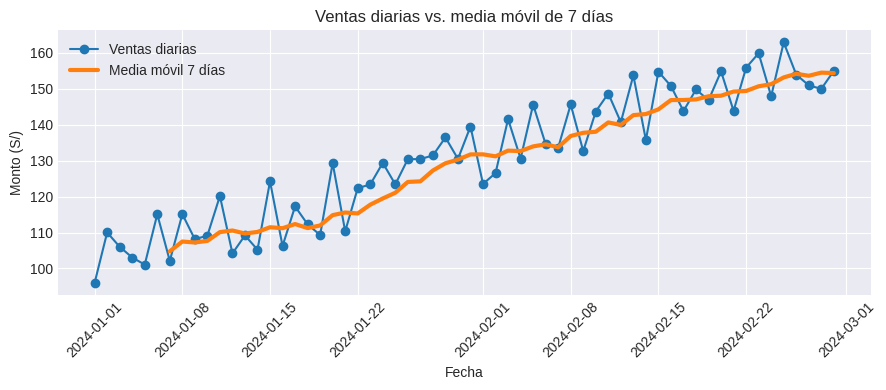

In [12]:
plt.figure(figsize=(9, 4))
plt.plot(df.index, df['monto'], label='Ventas diarias', marker='o')
plt.plot(df.index, df['monto_mm7'], label='Media móvil 7 días', linewidth=3)
plt.title('Ventas diarias vs. media móvil de 7 días')
plt.xlabel('Fecha')
plt.ylabel('Monto (S/)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()